БЛОГ ИНФЕРЕНСА

In [51]:
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


def run_inference(image_path, box_file_path, model, processor, label2id, threshold=0.85):
    image = Image.open(image_path).convert("RGB")
    w, h = image.size
    id2label = {v: k for k, v in label2id.items()}
    
    words, boxes = [], []
    try:
        with open(box_file_path, 'r', errors='ignore') as f:
            for line in f:
                parts = line.strip().split(',', 8)
                if len(parts) < 9: continue
                raw_box = [int(parts[0]), int(parts[1]), int(parts[4]), int(parts[5])]
                words.append(parts[8])
                boxes.append(raw_box)
    except FileNotFoundError:
        return [], [], []

    normalized_boxes = [[int(1000*(b[0]/w)), int(1000*(b[1]/h)), int(1000*(b[2]/w)), int(1000*(b[3]/h))] for b in boxes]
    
    encoding = processor(image, words, boxes=normalized_boxes, return_tensors="pt")
    word_ids = encoding.word_ids(batch_index=0)
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in encoding.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze()
        confidences, predictions = torch.max(probs, dim=-1)
        
    conf_list = confidences.tolist()
    pred_list = predictions.tolist()

    final_labels = ["O"] * len(words)
    final_confs = [0.0] * len(words)
    last_word_idx = None
    
    # Регулярка для валидных сумм (например: 10.00, 5,40.00)
    amount_pattern = re.compile(r'\d+[.,]\d{2}$')
    exclude_list = ["subtotal", "cash", "tax", "gst", "vat", "change", "items", "rounding", "balance"]

    for i, word_idx in enumerate(word_ids):
        if word_idx is not None and word_idx != last_word_idx:
            # Получаем текст и уверенность
            word_text = words[word_idx].strip()
            word_lower = word_text.lower()
            label = id2label[pred_list[i]]
            conf = conf_list[i]
            
            # --- ЛОГИКА ОЧИСТКИ АРТЕФАКТОВ ---

            # 1. Фильтр для COMPANY (желтый): Название бренда не может состоять из 1 символа
            if "COMPANY" in label.upper() and len(word_text) < 2:
                label = "O"

            # 2. Фильтр для DATE (зеленый): Одиночная цифра — это не дата
            if "DATE" in label.upper() and len(word_text) < 2:
                label = "O"

            # 3. Фильтр для TOTAL (красный): 
            if "TOTAL" in label.upper():
                # Убираем стоп-слова (налоги, сдача и т.д.)
                if any(x in word_lower for x in exclude_list):
                    label = "O"
                # Если в блоке нет цифр (например, точка или двоеточие)
                # Требуем очень высокую уверенность, чтобы оставить метку
                elif not any(c.isdigit() for c in word_text) and conf < 0.99:
                    label = "O"
                # Одиночный символ в TOTAL допустим только если это цифра и высокая уверенность
                elif len(word_text) < 2 and (not word_text.isdigit() or conf < 0.95):
                    label = "O"

            # 4. ОБЩИЙ ПРЕДОХРАНИТЕЛЬ:
            # Если любой токен короче 2 символов и модель сомневается (conf < 95%) — это шум
            if len(word_text) < 2 and conf < 0.95:
                label = "O"
            
            # Финальное сохранение меток
            if conf >= threshold:
                final_labels[word_idx] = label
                final_confs[word_idx] = conf
            else:
                final_labels[word_idx] = "O"
                
            last_word_idx = word_idx

    # --- ЭТАП ПРЕТЕНДЕНТОВ ---
    total_indices = [i for i, l in enumerate(final_labels) if "TOTAL" in l.upper()]
    
    if total_indices:
        scored_candidates = []
        for idx in total_indices:
            box = boxes[idx]
            txt = words[idx].strip()
            conf = final_confs[idx]
            
            # Считаем геометрический приоритет
            y_norm = box[3] / h  # Чем ниже, тем ближе к 1.0
            x_norm = box[2] / w  # Чем правее, тем ближе к 1.0
            
            # Бонусы
            is_amount = 1.0 if amount_pattern.search(txt) else 0.0
            has_digits = 0.5 if any(c.isdigit() for c in txt) else 0.0
            
            # Итоговый коэффициент (Y - самый важный фактор)
            score = (y_norm * 1.5) + (x_norm * 0.5) + (is_amount * 2.0) + has_digits + conf
            scored_candidates.append((score, idx))
        
        best_idx = max(scored_candidates, key=lambda x: x[0])[1]
        
        # Очищаем все, кроме чемпиона
        for idx in total_indices:
            if idx != best_idx:
                final_labels[idx] = "O"

    return words, boxes, final_labels
### 2. Визуализация в стиле автора

def visualize_prediction(image_path, words, boxes, labels):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Цвета теперь по категориям (независимо от B- или I-)
    category_colors = {
        "TOTAL": (255, 0, 0),    # Красный
        "DATE": (0, 255, 0),     # Зеленый
        "ADDRESS": (0, 0, 255),  # Синий
        "COMPANY": (255, 255, 0),# Желтый
        "O": (200, 200, 200)     # Серый
    }

    for box, label in zip(boxes, labels):
        # Извлекаем чистую категорию (например, из B-ADDRESS получаем ADDRESS)
        category = label.split("-")[-1] if "-" in label else label
        
        if category == "O":
            thickness = 1
            color = category_colors["O"]
        else:
            thickness = 2
            color = category_colors.get(category, (0, 0, 0))
            
            # Пишем текст только для начала сущности (B-)
            if label.startswith("B-"):
                cv2.putText(img, category, (box[0], box[1]-7), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), color, thickness)

    plt.figure(figsize=(10, 14))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Inference: {Path(image_path).name}")
    plt.show()

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

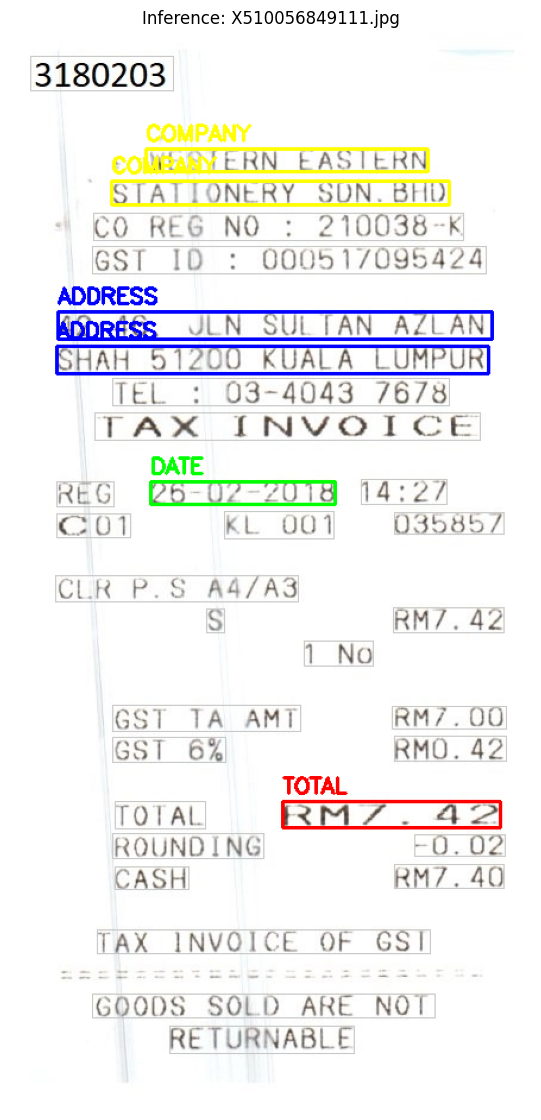

In [52]:
from transformers import LayoutLMv3ForTokenClassification, AutoProcessor
# Загрузка обученной модели (из папки сохранения)
model_path = "layoutlmv3_sroie_final" 
trained_model = LayoutLMv3ForTokenClassification.from_pretrained(model_path)
trained_processor = AutoProcessor.from_pretrained(model_path)

# Пути к тестовому примеру
test_img = "/kaggle/input/datasets/maxbegal/dataset-layoutlm/data/test/img/X510056849111.jpg"
test_box = "/kaggle/input/datasets/maxbegal/dataset-layoutlm/data/test/box/X510056849111.txt"

words, boxes, labels = run_inference(test_img, test_box, trained_model, trained_processor, label2id)
visualize_prediction(test_img, words, boxes, labels)